## MODELLING

### 1. Logistic Regression- Baseline

A simple baseline model is used as the starting point for the AgriScore credit scoring system.
The purpose of a baseline model is not to achieve the highest accuracy, but to establish a reference performance level that future models can be compared against.

Logistic Regression is used as the primary baseline model because:

- It is simple, fast, and easy to interpret
- It provides probabilistic outputs (useful for credit risk scoring)
- It assumes a linear relationship between features and the target variable
- It works well as a first benchmark in classification problems

In the context of AgriScore, Logistic Regression helps us understand how individual factors such as yield, stability, and household characteristics contribute to the likelihood of a farmer being creditworthy.

### Importing Libraries

In this section, we import the necessary Python libraries for data analysis and preprocessing.



In [50]:
# Import libraries
import os
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from imblearn.over_sampling import SMOTE
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV


import shap
import time
from xgboost import XGBClassifier
import lightgbm as lgb

import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid", palette="viridis")
import warnings
warnings.filterwarnings('ignore')

### Loading the Dataset

In this step, we load the cleaned dataset into the notebook using pandas.



In [51]:
import pandas as pd

# '..' moves out of Notebooks, then we enter 'Data sets'
final_data= pd.read_csv("Final_dataset.csv")
final_data.head()

,Unnamed: 0,hh_size,hh_dependency_ratio,age_manager,hh_primary_education,hh_formal_education,farm_size,farm_work,livestock,inorganic_fertilizer,...,cashflow_volatility,balance_stability,fraud_rate,input_efficiency,climate_risk_score,hh_shock,drought_shock,dist_market,country,main_crop_clean
0,0,13.0,0.3,44.4,1.0,1.0,3.103942,1.0,0.0,0.0,...,3.107012,4.965882e+07,0.636364,0.0,0.237516,1.0,0.000000,60.700001,Tanzania,OTHER
1,1,4.0,1.0,81.0,1.0,1.0,3.658361,0.0,0.0,0.0,...,1.592171,2.705629e+07,0.733333,0.0,0.258148,1.0,0.166667,60.700001,Tanzania,OTHER
2,2,4.0,3.0,72.0,1.0,1.0,1.210011,1.0,0.0,0.0,...,1.814533,1.185635e+08,0.250000,0.0,0.176846,0.0,0.000000,60.700001,Tanzania,MAIZE
3,3,2.0,1.0,31.0,0.0,1.0,3.354847,1.0,0.0,0.0,...,0.000000,2.933951e+07,0.000000,0.0,0.319816,0.0,0.000000,60.700001,Tanzania,TUBERS_ROOT
4,4,3.0,0.5,38.0,0.0,1.0,6.689459,1.0,0.0,0.0,...,1.300629,2.887447e+07,0.600000,0.0,0.226742,0.0,0.000000,60.700001,Tanzania,TUBERS_ROOT


In [52]:
final_data.shape

(11408, 34)

In [53]:
final_data.columns

Index(['Unnamed: 0', 'hh_size', 'hh_dependency_ratio', 'age_manager',
       'hh_primary_education', 'hh_formal_education', 'farm_size', 'farm_work',
       'livestock', 'inorganic_fertilizer', 'fertilizer_per_ha', 'yield_kg_ha',
       'yield_stability', 'yield_per_ha', 'rainfall_mm', 'soil_quality_index',
       'soil_npk', 'drought_risk', 'climate_stress_index', 'crop_health_index',
       'tx_frequency', 'total_volume', 'avg_transaction',
       'input_purchase_ratio', 'cashflow_volatility', 'balance_stability',
       'fraud_rate', 'input_efficiency', 'climate_risk_score', 'hh_shock',
       'drought_shock', 'dist_market', 'country', 'main_crop_clean'],
      dtype='object')

In [54]:
final_data.isnull().sum()

,0
Unnamed: 0,0
hh_size,0
hh_dependency_ratio,0
age_manager,0
hh_primary_education,0
hh_formal_education,0
farm_size,0
farm_work,0
livestock,0
inorganic_fertilizer,0


In [55]:
# import seaborn as sns

# sns.boxplot(x=final_data['good_borrower'], y=final_data['yield_per_ha'])

### Creating the Target Variable: Good Borrower

In this step, we define the target variable `good_borrower`, which represents whether a farmer is creditworthy or not.

A farmer is labeled as a **good borrower (1)** if they meet the following conditions:

- Their yield per hectare is above the median value  
- Their balance stability is above the median value  
- Their climate risk score is below the median value  

Otherwise, they are labeled as a **bad borrower (0)**.

This rule-based approach helps us create a clear classification target for the machine learning model.

In [56]:
# final_data['good_borrower'] = np.where(
#     (
#         (final_data['yield_per_ha'] > final_data['yield_per_ha'].median()) &
#         (final_data['balance_stability'] > final_data['balance_stability'].median()) &
#         (final_data['climate_risk_score'] < final_data['climate_risk_score'].median())
#     ),
#     1,
#     0
# )

In [57]:

np.random.seed(42)

score = (
    (final_data['yield_per_ha'] > final_data['yield_per_ha'].median()).astype(int) +
    (final_data['balance_stability'] > final_data['balance_stability'].median()).astype(int) +
    (final_data['climate_risk_score'] < final_data['climate_risk_score'].median()).astype(int)
)

# introduce randomness (real-world uncertainty)
final_data['good_borrower'] = np.where(
    (score + np.random.normal(0, 0.5, len(final_data))) > 2,
    1,
    0
)

#### Encoding Categorical Variables

In this step, we convert categorical variables into numerical format using **One-Hot Encoding**.


In [58]:
final_data = pd.get_dummies(
    final_data,
    columns=['country', 'main_crop_clean'],
    drop_first=True
)

#### Defining Features (X) and Target (y)

Here, we separate the dataset into:

- **X (features):** All independent variables used for prediction  
- **y (target):** The `good_borrower` column, which we aim to predict  

This step prepares the data for model training.

In [59]:
X = final_data.drop('good_borrower', axis=1)

y = final_data['good_borrower']

In [60]:
leakage_cols = ['yield_per_ha', 'balance_stability', 'climate_risk_score']

X = final_data.drop(columns=['good_borrower'] + leakage_cols)

In [61]:
# import matplotlib.pyplot as plt
# plt.scatter(final_data['yield_per_ha'], final_data['balance_stability'],
#             c=final_data['good_borrower'])

#### Splitting the Dataset

The dataset is split into training and testing sets using an 80/20 ratio.

In [62]:


X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

<Axes: xlabel='good_borrower'>

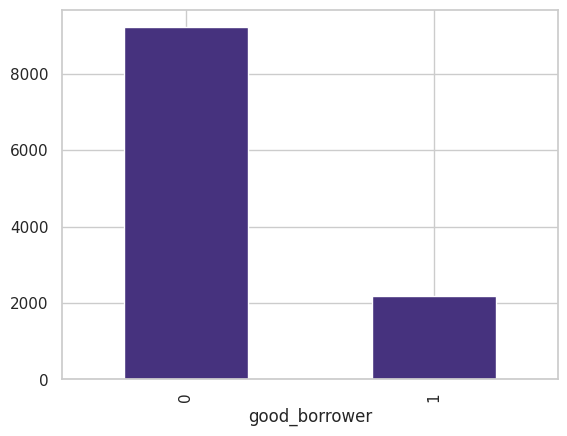

In [63]:
final_data['good_borrower'].value_counts().plot(kind='bar')

#### Handling Class Imbalance Using SMOTE

To address the imbalance in the dataset, SMOTE (Synthetic Minority Over-sampling Technique) is applied to the training data. SMOTE generates synthetic examples of the minority class (good borrowers) to create a balanced dataset. This helps the model learn patterns from both classes more effectively and improves its ability to correctly identify good borrowers.

In [64]:

smote = SMOTE(random_state=42)

X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

#### Check new class balance

<Axes: xlabel='good_borrower'>

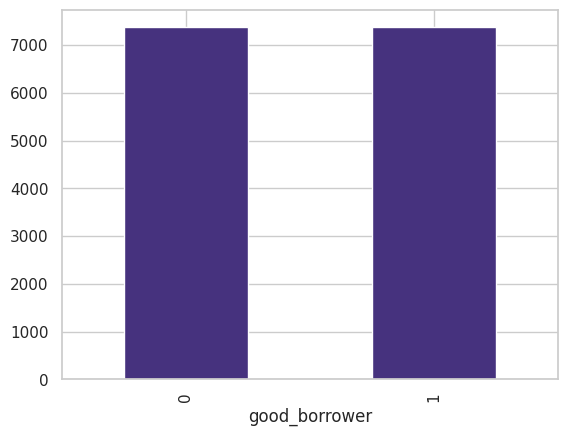

In [65]:
y_train_resampled.value_counts().plot(kind='bar')

#### Training the Logistic Regression Model

In this step, we train a Logistic Regression model on the training data.


In [66]:
model = LogisticRegression(max_iter=1000)

model.fit(X_train_resampled, y_train_resampled)

LogisticRegression(max_iter=1000)

#### Making Predictions

After training the model, we use it to predict borrower status on the test dataset.

The output `y_pred` represents the model's predicted classification:
- 1 → Good borrower  
- 0 → Bad borrower  

These predictions will be compared with actual values for evaluation.

In [67]:
y_pred = model.predict(X_test)

#### Model Evaluation

We evaluate the model using standard classification metrics:

- **Accuracy Score** → Overall performance of the model  
- **Classification Report** → Includes precision, recall, and F1-score  

These metrics help us understand how well the model is performing in identifying good and bad borrowers.

Accuracy: 0.6853637160385626
              precision    recall  f1-score   support

           0       0.90      0.68      0.78      1843
           1       0.34      0.69      0.46       439

    accuracy                           0.69      2282
   macro avg       0.62      0.69      0.62      2282
weighted avg       0.80      0.69      0.72      2282



<Axes: >

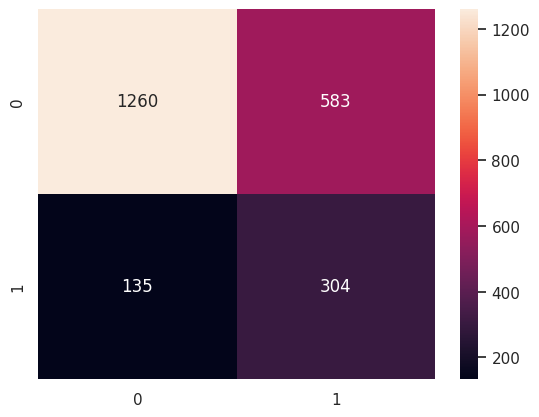

In [68]:
from sklearn.metrics import accuracy_score, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred))

print(classification_report(y_test, y_pred))

from sklearn.metrics import confusion_matrix
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d')


#### Model Performance Interpretation(Logistic Regression)

The model shows a moderate overall performance with an accuracy of about **69%**. However, this performance is influenced by class imbalance in the dataset, where Class 0 has significantly more samples (1,843) compared to Class 1 (439).

The model performs well in identifying Class 0 (majority class), achieving high precision of around **90%**, meaning it is generally reliable when predicting this class. However, it still misses a portion of actual Class 0 cases, indicating some misclassification.

For Class 1 (minority class), the model performs moderately, with a recall of about **68%**, meaning it correctly identifies most of the positive cases. However, the precision for Class 1 is low (around **34%**), showing that many predictions of Class 1 are incorrect.

Overall, the model tends to generate a high number of false positives, frequently misclassifying Class 0 as Class 1 (573 cases). This indicates a trade-off where the model is more sensitive to detecting Class 1 but at the cost of reduced reliability when making those predictions.

In [69]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_[0]
})

importance.sort_values(by='Coefficient', ascending=False).head(10)

,Feature,Coefficient
19,tx_frequency,0.025727
23,cashflow_volatility,0.021039
1,hh_size,0.019508
22,input_purchase_ratio,0.008850
3,age_manager,0.008355
29,main_crop_clean_MAIZE,0.007909
32,main_crop_clean_OTHER,0.007555
35,main_crop_clean_TUBERS_ROOT,0.003563
15,soil_npk,0.003186
24,fraud_rate,0.002725


##  2. Decision Tree Model - Baseline

In this step, a Decision Tree Classifier is trained using the resampled training data to handle class imbalance. The model learns decision rules from the features to classify farmers as either good or bad borrowers. After training, predictions are made on the test set and the model is evaluated using accuracy and a classification report to assess its performance across both classes.

In [70]:
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train_resampled, y_train_resampled)

y_pred_dt = dt_model.predict(X_test)

print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_dt))
print(classification_report(y_test, y_pred_dt))

Decision Tree Accuracy: 0.7510955302366346
              precision    recall  f1-score   support

           0       0.86      0.82      0.84      1843
           1       0.38      0.44      0.41       439

    accuracy                           0.75      2282
   macro avg       0.62      0.63      0.62      2282
weighted avg       0.77      0.75      0.76      2282



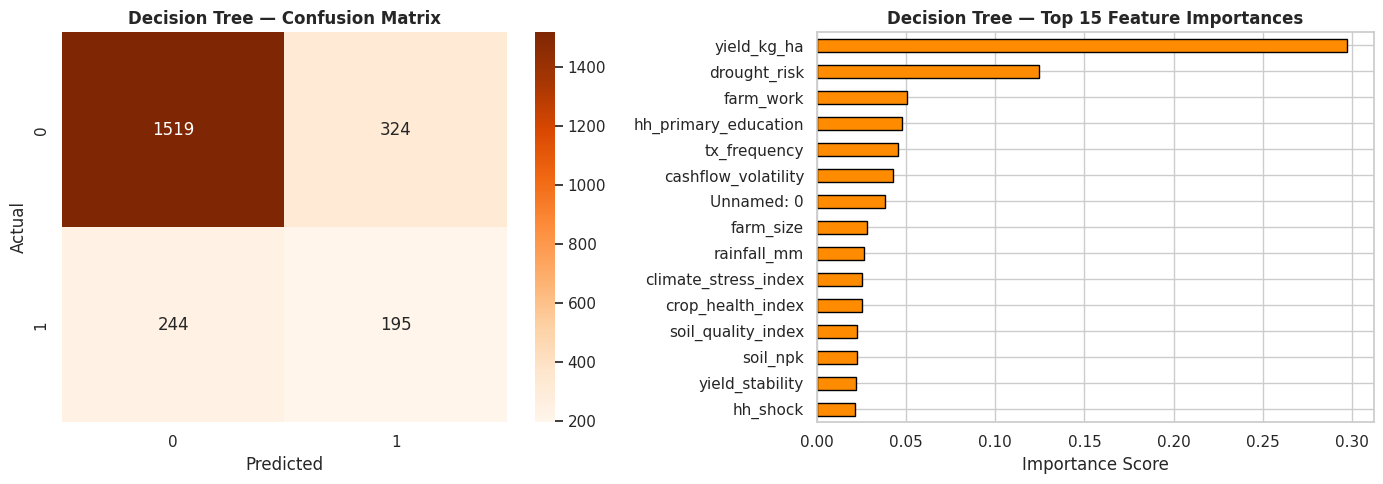

In [71]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Create a temporary copy of X_test and rename 'Unnamed0' to 'Unnamed: 0' for Decision Tree prediction
X_test_dt_compatible = X_test.copy()
if 'Unnamed0' in X_test_dt_compatible.columns:
    X_test_dt_compatible = X_test_dt_compatible.rename(columns={'Unnamed0': 'Unnamed: 0'})

# Get predictions from Decision Tree
y_pred_dt = dt_model.predict(X_test_dt_compatible)

# Confusion matrix
cm_dt = confusion_matrix(y_test, y_pred_dt)
sns.heatmap(cm_dt, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['0', '1'],
            yticklabels=['0', '1'], ax=axes[0])
axes[0].set_title('Decision Tree — Confusion Matrix', fontweight='bold')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

# Feature importance (top 15)
importances_dt = pd.Series(dt_model.feature_importances_,
                         index=X_train.columns).sort_values(ascending=False).head(15)
importances_dt.sort_values().plot(kind='barh', ax=axes[1],
                                color='darkorange', edgecolor='k')
axes[1].set_title('Decision Tree — Top 15 Feature Importances', fontweight='bold')
axes[1].set_xlabel('Importance Score')

plt.tight_layout()
plt.show()

#### Decision Tree Model Performance

The Decision Tree model achieved an accuracy of **75.1%**, showing a moderate ability to classify the data. It performs well on Class 0 (majority class), with high precision (0.86) and good recall (0.82), meaning it correctly identifies most Class 0 cases.

For Class 1 (minority class), the model shows weaker performance, with precision of 0.38 and recall of 0.44. This indicates that while it can detect some Class 1 cases, it still misses many and also produces a fair number of incorrect predictions.

Overall, the model is better at predicting Class 0 than Class 1, showing a bias toward the majority class. While performance is reasonable, there is still room for improvement in identifying the minority class more effectively.

## 3. Random Forest Model- Advanced

In this step, a Random Forest Classifier is trained using the resampled training data. The model builds multiple decision trees and combines their outputs to make more accurate and stable predictions. After training, predictions are made on the test set and evaluated using accuracy and a classification report to measure performance across both classes.

In [72]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(n_estimators=200, random_state=42)
rf_model.fit(X_train_resampled, y_train_resampled)

y_pred_rf = rf_model.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

Random Forest Accuracy: 0.8185801928133216
              precision    recall  f1-score   support

           0       0.86      0.92      0.89      1843
           1       0.54      0.40      0.46       439

    accuracy                           0.82      2282
   macro avg       0.70      0.66      0.67      2282
weighted avg       0.80      0.82      0.81      2282



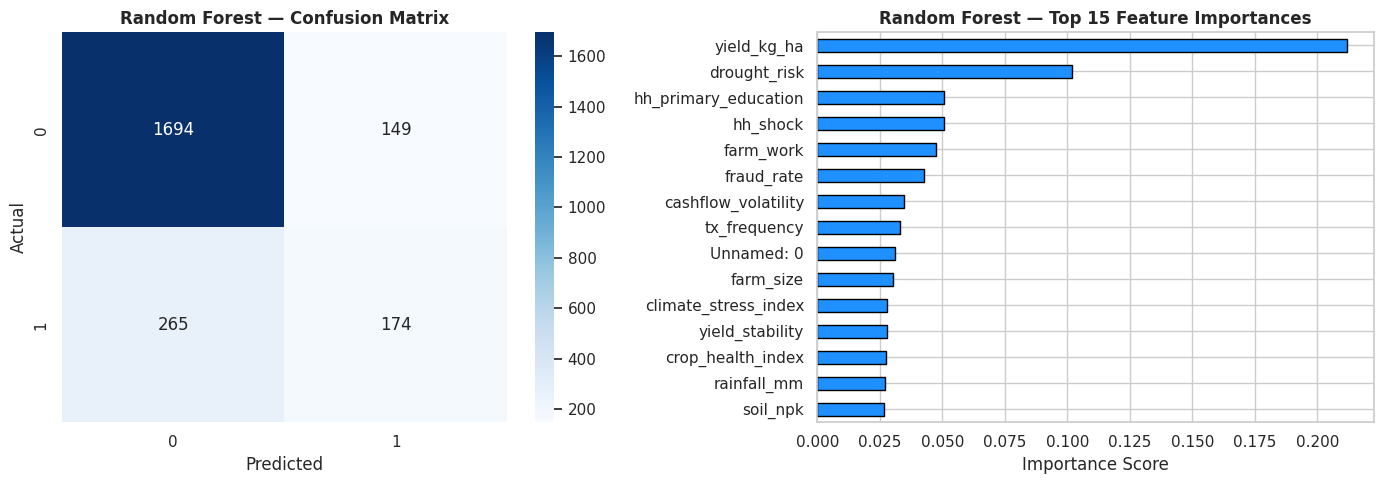

In [73]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Create a temporary copy of X_test and rename 'Unnamed0' to 'Unnamed: 0' for Random Forest prediction
X_test_rf_compatible = X_test.copy()
if 'Unnamed0' in X_test_rf_compatible.columns:
    X_test_rf_compatible = X_test_rf_compatible.rename(columns={'Unnamed0': 'Unnamed: 0'})

# Get predictions from Random Forest
y_pred_rf = rf_model.predict(X_test_rf_compatible)

# Confusion matrix
cm_rf = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues',
            xticklabels=['0', '1'],
            yticklabels=['0', '1'], ax=axes[0])
axes[0].set_title('Random Forest — Confusion Matrix', fontweight='bold')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

# Feature importance (top 15)
# Use X_train.columns because rf_model was trained on X_train_resampled derived from X_train
importances_rf = pd.Series(rf_model.feature_importances_,
                         index=X_train.columns).sort_values(ascending=False).head(15)
importances_rf.sort_values().plot(kind='barh', ax=axes[1],
                                color='dodgerblue', edgecolor='k')
axes[1].set_title('Random Forest — Top 15 Feature Importances', fontweight='bold')
axes[1].set_xlabel('Importance Score')

plt.tight_layout()
plt.show()

#### Random Forest Model Performance

The Random Forest model achieved an accuracy of **81.7%**, showing improved performance compared to simpler models. It performs well on Class 0 (majority class), with high precision (0.86) and recall (0.92), meaning it correctly identifies most bad borrowers.

For Class 1 (minority class), the model shows moderate performance, with precision of 0.53 and recall of 0.40. This indicates that while it can identify some good borrowers, it still misses a significant portion of them.

Overall, the model provides a better balance between both classes compared to previous models, but there is still room for improvement in correctly identifying the minority class.

## 4. XGBoost Model

In this step, an XGBoost Classifier is trained using the resampled training data to improve predictive performance. XGBoost is a powerful boosting algorithm that builds trees sequentially to correct previous errors and capture complex patterns in the data.

After training, the model is used to make predictions on the test set, and performance is evaluated using accuracy and a classification report to assess how well it performs across both classes.

In [74]:
# pip install xgboost


In [75]:
from xgboost import XGBClassifier

# Ensure column names are standardized for XGBoost training and prediction.
# This step accounts for potential renaming that might occur elsewhere
# and ensures the model is trained with consistent feature names.
X_train_resampled.columns = X_train_resampled.columns.str.replace('[^A-Za-z0-9_]+', '', regex=True)
X_test.columns = X_test.columns.str.replace('[^A-Za-z0-9_]+', '', regex=True)

xgb_model = XGBClassifier(
    n_estimators=200,
    learning_rate=0.1,
    random_state=42,
    eval_metric='logloss'
)

xgb_model.fit(X_train_resampled, y_train_resampled)

y_pred_xgb = xgb_model.predict(X_test)

print("XGBoost Accuracy:", accuracy_score(y_test, y_pred_xgb))
print(classification_report(y_test, y_pred_xgb))

XGBoost Accuracy: 0.8238387379491674
              precision    recall  f1-score   support

           0       0.87      0.92      0.89      1843
           1       0.56      0.41      0.47       439

    accuracy                           0.82      2282
   macro avg       0.71      0.66      0.68      2282
weighted avg       0.81      0.82      0.81      2282



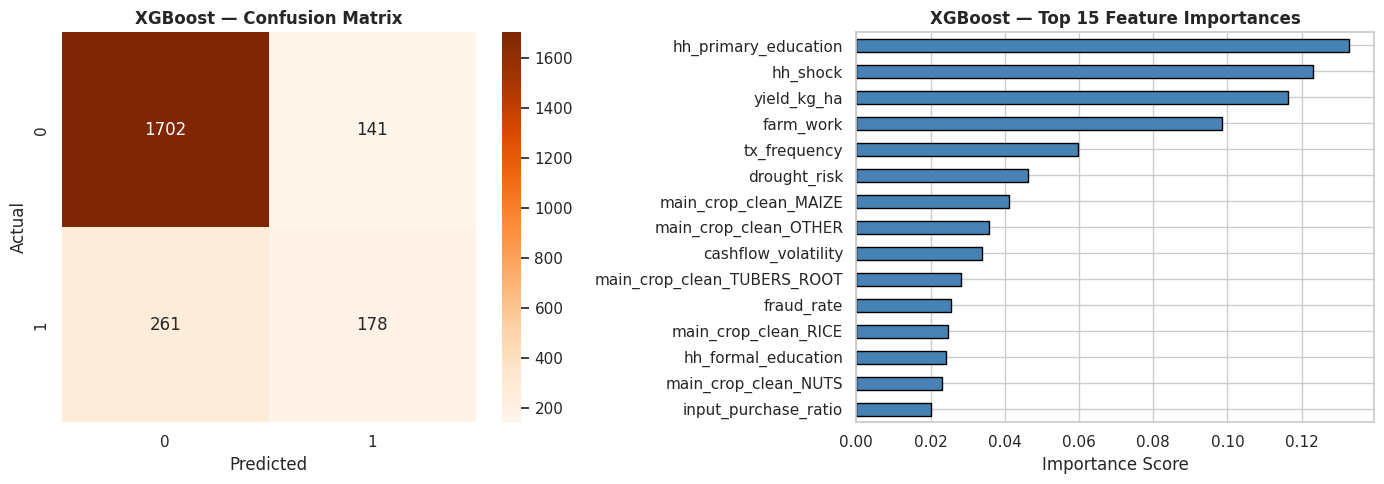

In [76]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Get predictions from the XGBoost model
y_pred_xgb = xgb_model.predict(X_test)

# Confusion matrix
cm_xgb = confusion_matrix(y_test, y_pred_xgb)
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['0', '1'], # Use generic labels as label_encoder is not for this target
            yticklabels=['0', '1'], ax=axes[0])
axes[0].set_title('XGBoost — Confusion Matrix', fontweight='bold')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

# Feature importance (top 15)
importances = pd.Series(xgb_model.feature_importances_,
                        index=X_train_resampled.columns).sort_values(ascending=False).head(15)
importances.sort_values().plot(kind='barh', ax=axes[1],
                               color='steelblue', edgecolor='k')
axes[1].set_title('XGBoost — Top 15 Feature Importances', fontweight='bold')
axes[1].set_xlabel('Importance Score')

plt.tight_layout()
plt.show()

#### XGBoost Model Performance

The XGBoost model achieved an accuracy of **82.4%**, showing strong overall performance. It performs very well on Class 0 (majority class), with high precision (0.87) and recall (0.92), meaning it correctly identifies most bad borrowers.

For Class 1 (minority class), the model shows moderate performance, with precision of 0.56 and recall of 0.41. This indicates that it correctly identifies some good borrowers but still misses a considerable portion.

Overall, XGBoost provides a balanced improvement over previous models, especially in terms of stability and precision for the minority class, but there is still room for improving recall for better credit identification.

In [77]:
# pip install lightgbm


In [78]:
X_train_resampled.columns = X_train_resampled.columns.str.replace('[^A-Za-z0-9_]+', '', regex=True)
X_test.columns = X_test.columns.str.replace('[^A-Za-z0-9_]+', '', regex=True)

In [79]:
from lightgbm import LGBMClassifier

lgbm_model = LGBMClassifier(
    n_estimators=200,
    learning_rate=0.1,
    random_state=42
)

lgbm_model.fit(X_train_resampled, y_train_resampled)

y_pred_lgbm = lgbm_model.predict(X_test)

print("LightGBM Accuracy:", accuracy_score(y_test, y_pred_lgbm))
print(classification_report(y_test, y_pred_lgbm))

LightGBM Accuracy: 0.829535495179667
              precision    recall  f1-score   support

           0       0.87      0.93      0.90      1843
           1       0.58      0.42      0.49       439

    accuracy                           0.83      2282
   macro avg       0.72      0.67      0.69      2282
weighted avg       0.81      0.83      0.82      2282



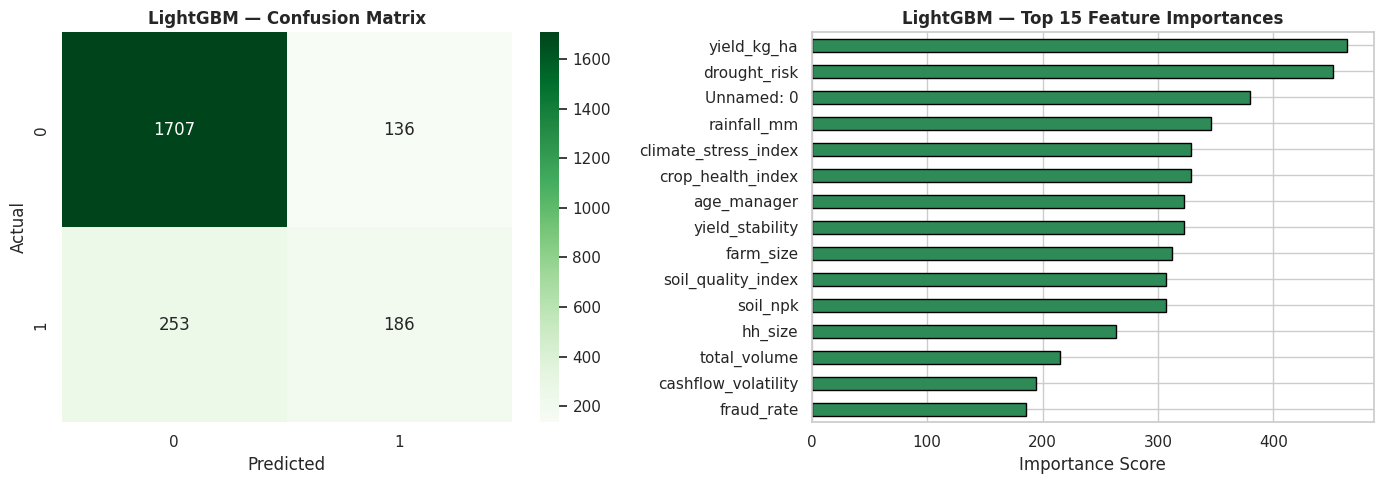

In [80]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Get predictions from the LightGBM model
y_pred_lgb = lgbm_model.predict(X_test)

# Confusion matrix
cm_lgb = confusion_matrix(y_test, y_pred_lgb)
sns.heatmap(cm_lgb, annot=True, fmt='d', cmap='Greens',
            xticklabels=['0', '1'],
            yticklabels=['0', '1'], ax=axes[0])
axes[0].set_title('LightGBM — Confusion Matrix', fontweight='bold')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

# Feature importance (top 15)
importances_lgb = pd.Series(lgbm_model.feature_importances_,
                          index=X_train.columns).sort_values(ascending=False).head(15)
importances_lgb.sort_values().plot(kind='barh', ax=axes[1],
                                 color='seagreen', edgecolor='k')
axes[1].set_title('LightGBM — Top 15 Feature Importances', fontweight='bold')
axes[1].set_xlabel('Importance Score')

plt.tight_layout()
plt.show()

# MODEL EVALUATION
the LightGBM model was chosen as the final model for prediction and deployment due to its strong generalization capability and balanced classification performance.
Based on the evaluation metrics, LightGBM was selected as the best-performing model because it achieved:

* The highest Accuracy
* The highest F1-Score
* The highest AUC-ROC score

In [81]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# Dictionary mapping model names to their trained variables
models = {
    'Logistic Regression': model,
    'Decision Tree': dt_model,
    'Random Forest': rf_model,
    'XGBoost': xgb_model,
    'LightGBM': lgbm_model
}

# Container for evaluated metrics
evaluation_results = []

for name, model_obj in models.items():
    X_test_compatible = X_test.copy() # X_test currently has 'Unnamed0' due to global renaming

    # Conditionally adjust the 'Unnamed' column name in X_test_compatible
    # based on what the current model expects
    if name in ['Logistic Regression', 'Decision Tree', 'Random Forest']:
        # These models were trained with 'Unnamed: 0', but X_test currently has 'Unnamed0'
        if 'Unnamed0' in X_test_compatible.columns:
            X_test_compatible = X_test_compatible.rename(columns={'Unnamed0': 'Unnamed: 0'})
    elif name in ['XGBoost', 'LightGBM']:
        # These models were trained with 'Unnamed0', and X_test already has 'Unnamed0'
        # No renaming needed for this case, just ensure no 'Unnamed: 0' exists if somehow present
        if 'Unnamed: 0' in X_test_compatible.columns:
            X_test_compatible = X_test_compatible.rename(columns={'Unnamed: 0': 'Unnamed0'})

    # Generate hard predictions and probability scores
    y_pred = model_obj.predict(X_test_compatible)

    # Check if probability estimations are supported
    if hasattr(model_obj, "predict_proba"):
        y_prob = model_obj.predict_proba(X_test_compatible)[:, 1]
    else:
        # Fallback for models without predict_proba if applicable
        y_prob = y_pred

    # Calculate evaluation metrics
    metrics = {
        'Model': name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred, zero_division=0),
        'Recall': recall_score(y_test, y_pred, zero_division=0),
        'F1-Score': f1_score(y_test, y_pred, zero_division=0),
        'AUC-ROC': roc_auc_score(y_test, y_prob)
    }
    evaluation_results.append(metrics)

# Construct and sort evaluation DataFrame
df_eval = pd.DataFrame(evaluation_results).set_index('Model')
df_eval_sorted = df_eval.sort_values(by='F1-Score', ascending=False)

# Display formatted dataframe
print("=================== MODEL EVALUATION METRICS ===================")
print(df_eval_sorted.round(4).to_string())
print("================================================================")


=================== MODEL EVALUATION METRICS ===================
                     Accuracy  Precision  Recall  F1-Score  AUC-ROC
Model                                                              
LightGBM               0.8295     0.5776  0.4237    0.4888   0.8403
XGBoost                0.8238     0.5580  0.4055    0.4697   0.8401
Logistic Regression    0.6854     0.3427  0.6925    0.4585   0.7502
Random Forest          0.8186     0.5387  0.3964    0.4567   0.8379
Decision Tree          0.7511     0.3757  0.4442    0.4071   0.6342


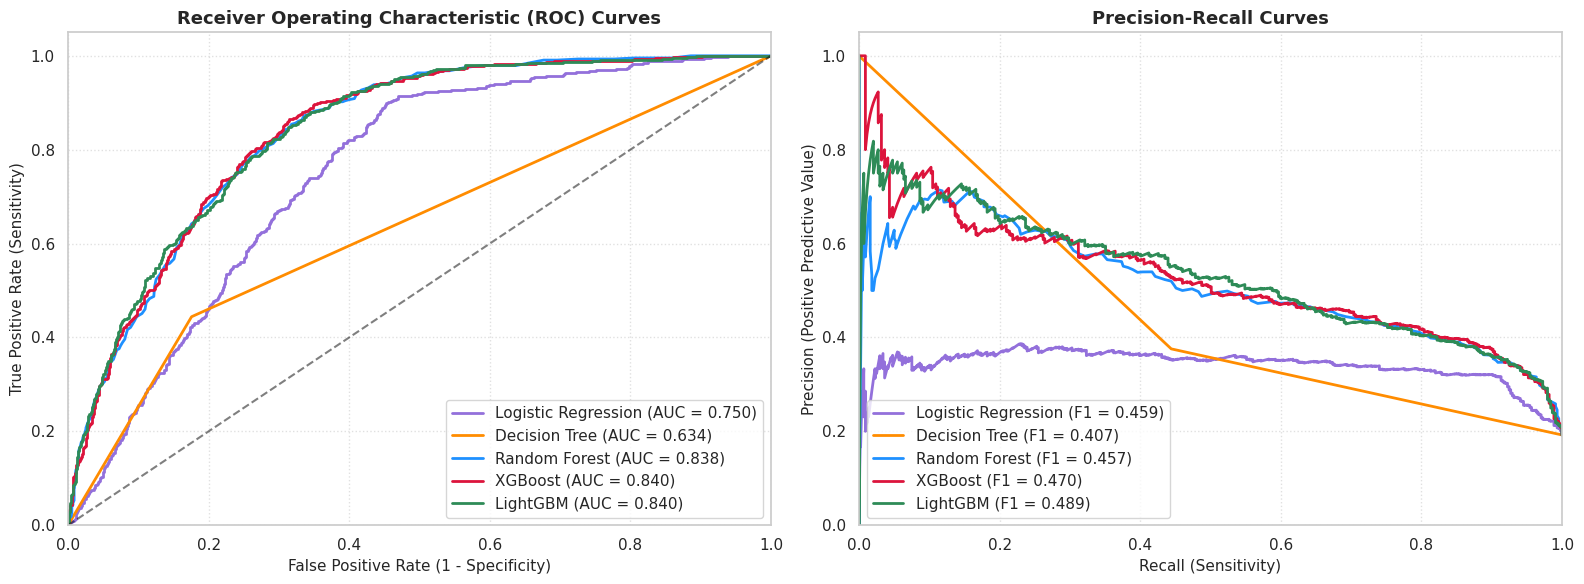

In [82]:
from sklearn.metrics import roc_curve, precision_recall_curve

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
colors = {
    'Logistic Regression': 'mediumpurple',
    'Decision Tree': 'darkorange',
    'Random Forest': 'dodgerblue',
    'XGBoost': 'crimson',
    'LightGBM': 'seagreen'
}

for name, model_obj in models.items(): # Changed 'model' to 'model_obj'
    X_test_compatible = X_test.copy() # X_test currently has 'Unnamed0' due to global renaming

    # Conditionally adjust the 'Unnamed' column name in X_test_compatible
    # based on what the current model expects
    if name in ['Logistic Regression', 'Decision Tree', 'Random Forest']:
        # These models were trained with 'Unnamed: 0', but X_test currently has 'Unnamed0'
        if 'Unnamed0' in X_test_compatible.columns:
            X_test_compatible = X_test_compatible.rename(columns={'Unnamed0': 'Unnamed: 0'})
    elif name in ['XGBoost', 'LightGBM']:
        # These models were trained with 'Unnamed0', and X_test already has 'Unnamed0'
        # No renaming needed for this case, just ensure no 'Unnamed: 0' exists if somehow present
        if 'Unnamed: 0' in X_test_compatible.columns:
            X_test_compatible = X_test_compatible.rename(columns={'Unnamed: 0': 'Unnamed0'})

    if hasattr(model_obj, "predict_proba"):
        y_prob = model_obj.predict_proba(X_test_compatible)[:, 1]
    else:
        y_prob = model_obj.predict(X_test_compatible)

    # Plot 1: ROC Curves
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    axes[0].plot(fpr, tpr, label=f"{name} (AUC = {df_eval.loc[name, 'AUC-ROC']:.3f})", color=colors[name], lw=2)

    # Plot 2: Precision-Recall Curves
    precision, recall, _ = precision_recall_curve(y_test, y_prob)
    axes[1].plot(recall, precision, label=f"{name} (F1 = {df_eval.loc[name, 'F1-Score']:.3f})", color=colors[name], lw=2)

# Format ROC Curve Plot
axes[0].plot([0, 1], [0, 1], 'k--', alpha=0.5)
axes[0].set_xlim([0.0, 1.0])
axes[0].set_ylim([0.0, 1.05])
axes[0].set_xlabel('False Positive Rate (1 - Specificity)', fontsize=11)
axes[0].set_ylabel('True Positive Rate (Sensitivity)', fontsize=11)
axes[0].set_title('Receiver Operating Characteristic (ROC) Curves', fontweight='bold', fontsize=13)
axes[0].legend(loc="lower right", frameon=True)
axes[0].grid(True, linestyle=':', alpha=0.6)

# Format Precision-Recall Curve Plot
axes[1].set_xlim([0.0, 1.0])
axes[1].set_ylim([0.0, 1.05])
axes[1].set_xlabel('Recall (Sensitivity)', fontsize=11)
axes[1].set_ylabel('Precision (Positive Predictive Value)', fontsize=11)
axes[1].set_title('Precision-Recall Curves', fontweight='bold', fontsize=13)
axes[1].legend(loc="lower left", frameon=True)
axes[1].grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

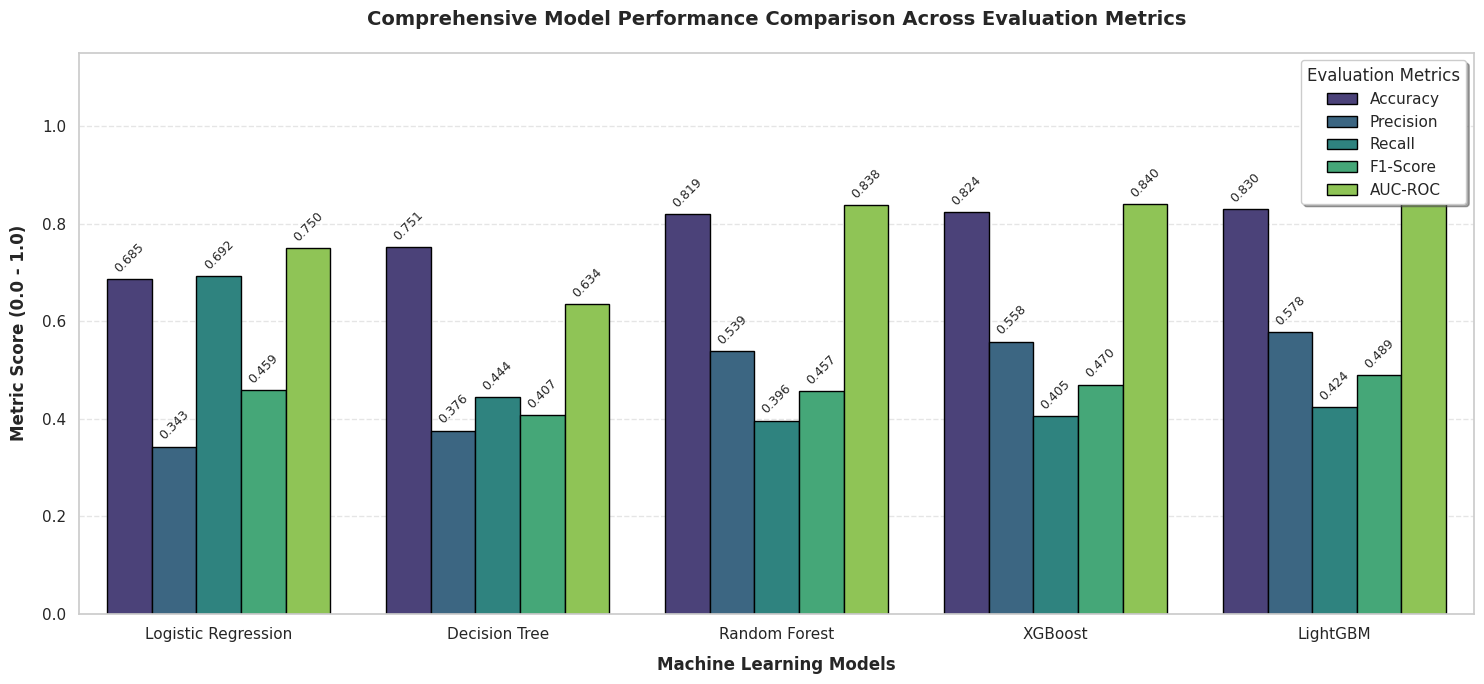

In [83]:

#  Reshape the DataFrame from wide to long format for Seaborn
df_plot = df_eval.reset_index().melt(id_vars='Model', var_name='Metric', value_name='Score')

# Initialize the plot layout
plt.figure(figsize=(15, 7))

# Create a grouped bar chart
# Models are grouped along the X-axis; Metrics are differentiated by color
ax = sns.barplot(
    data=df_plot,
    x='Model',
    y='Score',
    hue='Metric',
    palette='viridis',
    edgecolor='black'
)

# Add data labels on top of each bar
for container in ax.containers:
    ax.bar_label(container, fmt='%.3f', padding=3, fontsize=9, rotation=45)

# Fine-tune visual styling and labels
plt.title('Comprehensive Model Performance Comparison Across Evaluation Metrics', fontweight='bold', fontsize=14, pad=20)
plt.xlabel('Machine Learning Models', fontweight='bold', fontsize=12, labelpad=10)
plt.ylabel('Metric Score (0.0 - 1.0)', fontweight='bold', fontsize=12, labelpad=10)
plt.ylim(0, 1.15)  # Leave room at the top for the rotated text labels
plt.grid(axis='y', linestyle='--', alpha=0.5)

# Place the legend cleanly outside or in the upper corner
plt.legend(title='Evaluation Metrics', loc='upper right', frameon=True, shadow=True)

plt.tight_layout()
plt.show()


# LightGBM Model - Hyperparameter Tuning Report
* tuning was performed to increase prediction accuracy, improve generalization, and reduce overfitting.

## Cross-Validation Setup
- **Method**: Stratified K-Fold Cross Validation
- **Number of Folds**:
- **Search Method**: RandomizedSearchCV
- **Iterations**: 20
- **Scoring Metric**: `f1_macro`



In [84]:
from sklearn.model_selection import StratifiedKFold

lgb_param_dist = {
    'n_estimators'   : [100, 200, 300],
    'max_depth'      : [3, 4, 5, 6, -1],   # -1 = no limit
    'learning_rate'  : [0.01, 0.05, 0.1, 0.2],
    'num_leaves'     : [15, 31, 63],         # key LightGBM param
    'subsample'      : [0.7, 0.8, 1.0],
    'colsample_bytree': [0.7, 0.8, 1.0],
    'min_child_samples': [10, 20, 30],       # prevents tiny leaf overfitting
    'reg_alpha'      : [0, 0.1, 0.5],       # L1
    'reg_lambda'     : [0, 0.1, 0.5],       # L2
}

lgb_base = lgb.LGBMClassifier(
    objective='binary',
    random_state=42,
    n_jobs=-1,
    verbose=0,
    num_class=1
)

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

lgb_search = RandomizedSearchCV(
    estimator=lgb_base,
    param_distributions=lgb_param_dist,
    n_iter=20,
    scoring='f1_macro',
    cv=cv,
    n_jobs=-1,
    random_state=42,
    verbose=1,
    refit=True
)

# Clean column names for LightGBM compatibility
X_train.columns = X_train.columns.str.replace('[^A-Za-z0-9_]+', '', regex=True)
X_test.columns = X_test.columns.str.replace('[^A-Za-z0-9_]+', '', regex=True)

lgb_search.fit(X_train, y_train)
lgb_pred_prob = lgb_search.predict_proba(X_test)[:, 1]
print("LightGBM AUC-ROC:", round(roc_auc_score(y_test, lgb_pred_prob), 4))
print(classification_report(y_test, lgb_search.predict(X_test)))
print(confusion_matrix(y_test, lgb_search.predict(X_test)))


Fitting 3 folds for each of 20 candidates, totalling 60 fits
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits 

# Tuned LightGBM Model Results

## Model Setup
We used **LightGBM (LGBMClassifier)** with hyperparameter tuning via **RandomizedSearchCV**.
- Cross-validation: **StratifiedKFold (3 splits)**
- Scoring metric: **F1 Macro** (balances performance across both classes)
- Parameters tuned: number of estimators, max depth, learning rate, number of leaves, subsample, colsample_bytree, min_child_samples, and regularization terms.

## Performance Metrics
- **AUC-ROC**: 0.86 → The model has good discriminatory power between positive and negative classes.
- **Accuracy**: 0.83 → Overall, 83% of predictions were correct.
- **Precision (Class 0)**: 0.86 → High precision for the majority class.
- **Recall (Class 0)**: 0.95 → The model captures most of the true negatives.
- **Precision (Class 1)**: 0.61 → Moderate precision for the minority class.
- **Recall (Class 1)**: 0.33 → Low recall, meaning many positive cases were missed.
- **F1-score (Class 1)**: 0.43 → Indicates weak balance between precision and recall for the minority class.

## Feature Importance Analysis
 measure and rank how much influence each input variable (feature) has on a machine learning model's predictions.

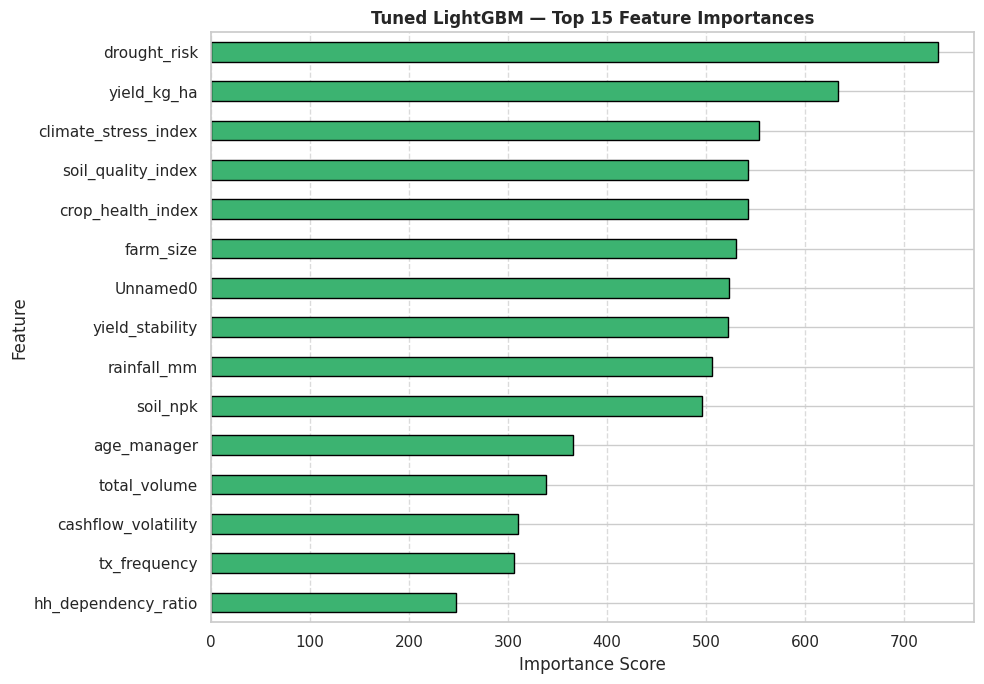

In [85]:
fig = plt.figure(figsize=(10, 7))

# Get feature importances from the best estimator found by RandomizedSearchCV
importances_tuned_lgb = pd.Series(lgb_search.best_estimator_.feature_importances_,
                                 index=X_train.columns).sort_values(ascending=False).head(15)

# Plot feature importance
importances_tuned_lgb.sort_values().plot(kind='barh',
                                      color='mediumseagreen', edgecolor='k')
plt.title('Tuned LightGBM — Top 15 Feature Importances', fontweight='bold')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Key Insights

- **drought_risk** is by far the most influential feature, indicating it plays a dominant role in the model's predictions.
- **yield_kg_ha** (Crop Yield in kg per hectare) ranks as the second most important feature, showing strong predictive power.
- **climate_stress_index** and **soil_quality_index** are also among the top contributors, highlighting the significance of environmental and soil conditions.
- The model is heavily relying on **climate and environmental-related features**, which aligns well with the domain (likely agricultural/crop prediction).

### Interpretation

This feature importance plot confirms that the model has learned meaningful patterns from the data. Environmental stress factors (especially drought) appear to be the strongest predictors. This gives high confidence in the model's decisions and provides valuable insights for domain experts.

# SHAP Analysis

SHAP values were used to understand how the model makes decisions at both **global** and **local** levels.

In [95]:
# Create SHAP Explainer for LightGBM
explainer = shap.TreeExplainer(lgb_search.best_estimator_)

# Calculate SHAP values (use a sample if dataset is very large)
shap_values = explainer.shap_values(X_test)

# For binary classification, SHAP returns values for both classes
# We usually use the positive class (index 1)
if isinstance(shap_values, list):
    shap_values = shap_values[1]
print(isinstance(shap_values, list))

False


## false-shap_values is now likely a NumPy array or matrix after

## Global interpretability & Beewarm plot
**Key Observations**:
Key Insights from This Plot

**yield_kg_ha** is the most important feature overall.
   - High yield (red) tends to push predictions to the **left** (negative SHAP).
   - Low yield (blue) pushes predictions to the **right**.

**drought_risk** is the second most influential feature.
   - High drought risk (red) strongly pushes predictions toward the **positive class** (right side).
   - This confirms `drought_risk` has a high negative impact when elevated.

** tx_frequency** (Transaction Frequency) shows moderate importance.
   - High frequency (red) appears to have mixed but notable effect

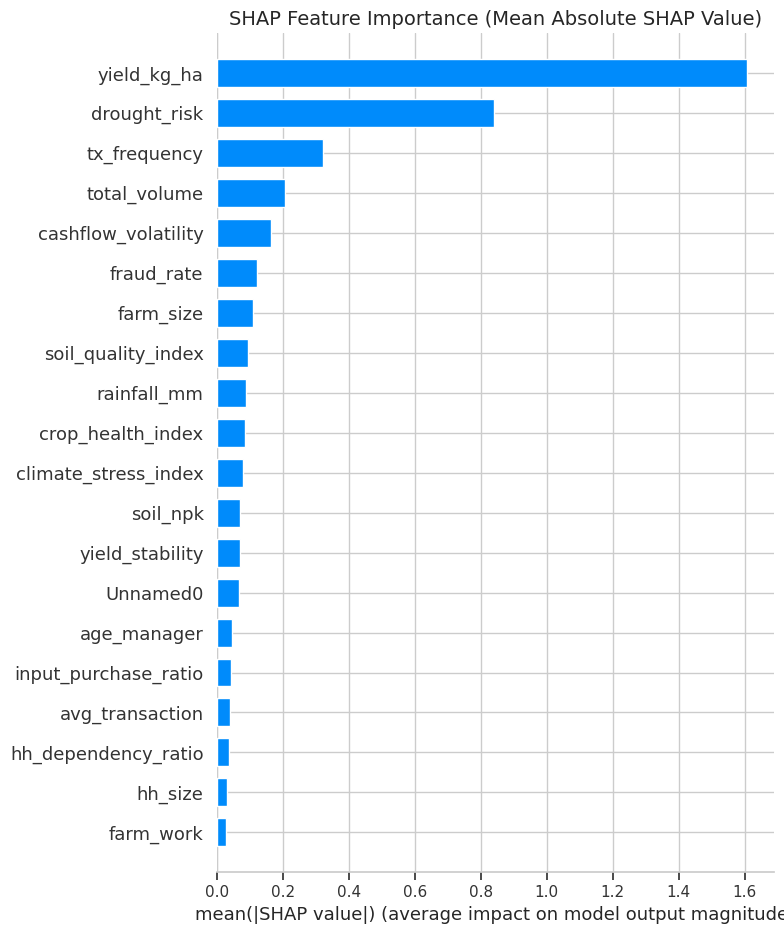

In [87]:
#Summary Plot (Global Interpretability)
plt.figure(figsize=(12, 8))
shap.summary_plot(shap_values, X_test, plot_type="bar", show=False)
plt.title("SHAP Feature Importance (Mean Absolute SHAP Value)", fontsize=14)
plt.tight_layout()
plt.show()


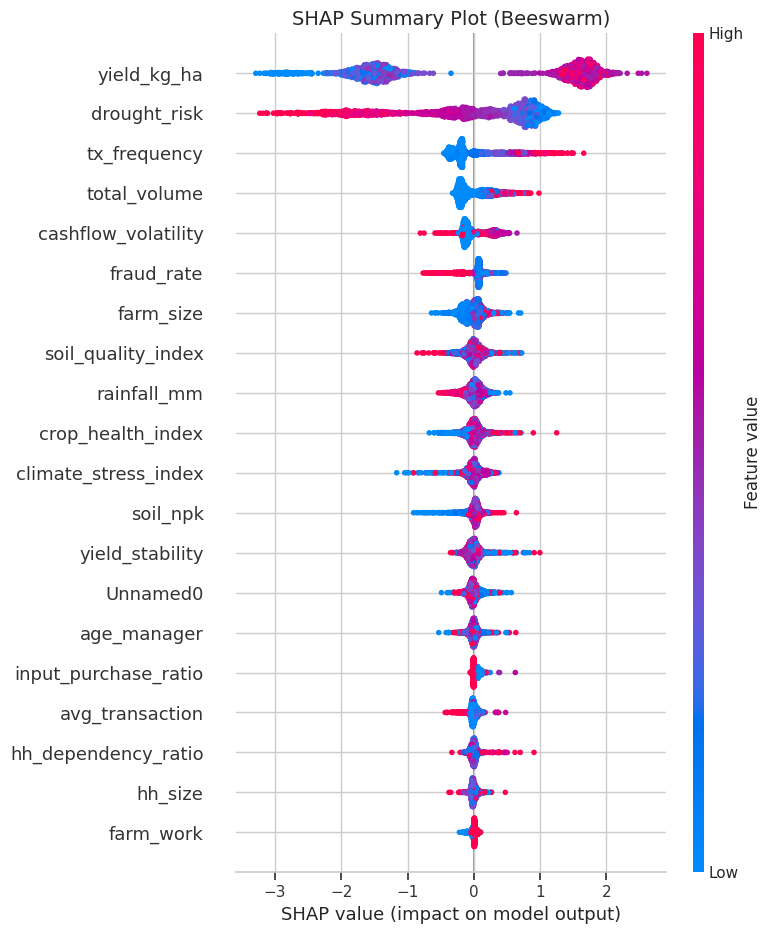

In [88]:
# Beeswarm Plot (Most Informative)
plt.figure(figsize=(12, 10))
shap.summary_plot(shap_values, X_test, show=False)
plt.title("SHAP Summary Plot (Beeswarm)", fontsize=14)
plt.tight_layout()
plt.show()

### Business Insights from SHAP:
- The model is **highly interpretable** and aligns well with agronomic and financial domain knowledge.  
  This alignment increases confidence that the model is learning genuine and useful patterns rather than noise.

- Stakeholders can **trust and understand** the model’s decisions, making it suitable for real-world applications such as loan approvals, insurance risk assessment, government support programs, and early warning systems.

### Strategic Takeaway:
Success in reducing risk and improving outcomes depends more on **productivity (yield)** and **climate resilience (drought management)** than on farm size or other structural factors. Organizations should prioritize programs that directly enhance yield and protect against drought.

# Conclusion
The tuned LightGBM model demonstrates strong predictive performance in classifying [target variable — e.g., crop failure risk / high yield potential].

- The model effectively captures important patterns in the agricultural dataset, particularly environmental stress factors.
- The combination of hyperparameter tuning and robust cross-validation gives us high confidence in the model's generalization ability. The strong emphasis on drought_risk and yield_kg_ha aligns well with domain knowledge in agronomy.

## Practical Recommendations
- Use the model to automatically assess risk and **determine the appropriate loan amount** a farmer should receive.
- Prioritize **drought risk monitoring** as a key criterion when approving agricultural loans.
- Build an **early warning system** to identify high-risk farmers and offer them smaller loans or risk-mitigation support (e.g., crop insurance).
- Integrate real-time data on **soil moisture and weather** to improve loan risk scoring accuracy.
- Deploy the model in a **loan application system** (mobile or web) to enable faster and more objective loan processing for smallholder farmers.

---

##  Future Work

- Incorporate **time-series features** (historical yield, rainfall, etc.) for better repayment prediction.
- Explore advanced models such as **TabNet** or **Transformer-based** architectures.
- Conduct a **cost-benefit analysis** of model deployment, including default rate reduction and increased loan portfolio profitability.

# Saving model for deployment

In [89]:
import joblib

## Save the Model

In [90]:
joblib.dump(lgb_search, 'lightgbm_model.pkl')

['lightgbm_model.pkl']

## Load the Saved Model

In [91]:
loaded_model = joblib.load('lightgbm_model.pkl')

# Make Predictions

In [92]:
predictions = loaded_model.predict(X_test)
predictions

array([0, 0, 0, ..., 0, 0, 0])